In [1]:
import sys
sys.path.append('../src')
from data_loader import update_db, load_from_db, get_db_summary
get_db_summary()

---------------------------------------------
No. Tickers : 40
No. Rows    : 51,605
---------------------------------------------


,Ticker,rows,start_date,end_date
0,ACB,1319,2021-01-04,2026-04-21
1,BCM,1319,2021-01-04,2026-04-21
2,BID,1319,2021-01-04,2026-04-21
3,BVH,1319,2021-01-04,2026-04-21
4,CTG,1319,2021-01-04,2026-04-21
5,DGC,1319,2021-01-04,2026-04-21
6,EIB,1319,2021-01-04,2026-04-21
7,FPT,1319,2021-01-04,2026-04-21
8,GAS,1319,2021-01-04,2026-04-21
9,GMD,1319,2021-01-04,2026-04-21


In [2]:
import sys
sys.path.append('../src')
from data_loader import update_db, load_from_db, get_db_summary
update_db()

✅ Table Stock_Prices ready
📥 Fetching 30 tickers | 2021-01-01 → 2026-04-22
   Source: vnstock3 VCI (fallback: yfinance)



📦 **Vnstock 3.5.1 is available**
Current: 3.5.0 (Python 3.13 (venv))
Update: `D:\Projects\vn-portfolio-optimizer\venv\Scripts\python.exe -m pip install vnstock --upgrade`
Release: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban

📦 **Vnai 2.4.6 is available**
Current: 2.4.0 (Python 3.13 (venv))
Update: `D:\Projects\vn-portfolio-optimizer\venv\Scripts\python.exe -m pip install vnai --upgrade`
Release: https://pypi.org/project/vnai/#history

Thư viện `vnstock3` đã được hợp nhất với tên gọi `vnstock`. Phiên bản mới nhất 3.5.1 đã có mặt.Vui lòng chuyển đổi gói thư viện thành `vnstock` để luôn nhận bản cập nhật với câu lệnh : `pip install vnstock --upgrade`.
Lịch sử phiên bản: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Phiên bản hiện tại 3.2.1

  ⚠️  ACB   →     0 rows
  ⚠️  BID   →     0 rows
  ⚠️  CTG   →     0 rows
  ⚠️  DGC   →     0 rows
  ⚠️  FPT   →     0 rows
  ⚠️  GAS   →     0 rows
  ⚠️  GVR   →     0 rows
  ⚠️  HDB   →     0 rows
  ⚠️  HPG   →     0 rows
  ⚠️  LPB   →     0 rows
  ⚠️  MBB   →     0 rows
  ⚠️  MSN   →     0 rows
  ⚠️  MWG   →     0 rows
  ⚠️  PLX   →     0 rows
  ⚠️  SAB   →     0 rows
  ⚠️  SHB   →     0 rows
  ⚠️  SSB   →     0 rows
  ⚠️  SSI   →     0 rows
  ⚠️  STB   →     0 rows
  ⚠️  TCB   →     0 rows
  ⚠️  TPB   →     0 rows
  ⚠️  VCB   →     0 rows
  ⚠️  VHM   →     0 rows
  ⚠️  VIB   →     0 rows
  ⚠️  VIC   →     0 rows
  ⚠️  VJC   →     0 rows
  ⚠️  VNM   →     0 rows
  ⚠️  VPB   →     0 rows
  ⚠️  VPL   →     0 rows
  ⚠️  VRE   →     0 rows

✅ Done. Total new rows: 0

📊 DB Summary:
---------------------------------------------
No. Tickers : 40
No. Rows    : 51,605
---------------------------------------------
Ticker  rows start_date   end_date
   ACB  1319 2021-01-04 2026-04-21
   BCM  

In [3]:
import sys
sys.path.append('../src')
from data_loader import load_from_db
import numpy as np

df = load_from_db('VCB', '2021-01-01', '2026-04-22')

# Tính return rồi export
df['Simple_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Export ra Excel
df.to_excel('../reports/vcb_returns_verify.xlsx')
print(f"✅ Exported {len(df)} rows")
print(f"File: reports/vcb_returns_verify.xlsx")

✅ Exported 1319 rows
File: reports/vcb_returns_verify.xlsx


In [4]:
from vnstock import Vnstock
import pandas as pd

# Test đủ 10 mã
tickers = ['VCB', 'VNM', 'HPG', 'FPT', 'MWG', 'VIC', 'GAS', 'BID', 'CTG', 'TCB']

results = []
for t in tickers:
    try:
        stock = Vnstock().stock(symbol=t, source='VCI')
        df = stock.quote.history(start='2024-01-01', end='2024-01-31', interval='1D')
        results.append({
            'Ticker': t,
            'Rows': len(df),
            'Close_min': df['close'].min(),
            'Close_max': df['close'].max(),
            'Status': '✅'
        })
    except Exception as e:
        results.append({
            'Ticker': t,
            'Rows': 0,
            'Close_min': None,
            'Close_max': None,
            'Status': f'❌ {type(e).__name__}'
        })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

Ticker  Rows Close_min Close_max     Status
   VCB     0      None      None ❌ KeyError
   VNM     0      None      None ❌ KeyError
   HPG     0      None      None ❌ KeyError
   FPT     0      None      None ❌ KeyError
   MWG     0      None      None ❌ KeyError
   VIC     0      None      None ❌ KeyError
   GAS     0      None      None ❌ KeyError
   BID     0      None      None ❌ KeyError
   CTG     0      None      None ❌ KeyError
   TCB     0      None      None ❌ KeyError


In [5]:
import sys
sys.path.append('../src')
from data_loader import update_db, load_from_db, get_db_summary
update_db()

✅ Table Stock_Prices ready
📥 Fetching 30 tickers | 2021-01-01 → 2026-04-22
   Source: vnstock3 VCI (fallback: yfinance)

  ✅ ACB   →     1 rows
  ✅ BID   →     1 rows
  ✅ CTG   →     1 rows
  ✅ DGC   →     1 rows
  ✅ FPT   →     1 rows
  ✅ GAS   →     1 rows
  ✅ GVR   →     1 rows
  ✅ HDB   →     1 rows
  ✅ HPG   →     1 rows
  ✅ LPB   →     1 rows
  ✅ MBB   →     1 rows
  ✅ MSN   →     1 rows
  ✅ MWG   →     1 rows
  ✅ PLX   →     1 rows
  ✅ SAB   →     1 rows
  ✅ SHB   →     1 rows
  ✅ SSB   →     1 rows
  ✅ SSI   →     1 rows
  ✅ STB   →     1 rows
  ✅ TCB   →     1 rows
  ✅ TPB   →     1 rows
  ✅ VCB   →     1 rows
  ✅ VHM   →     1 rows
  ✅ VIB   →     1 rows
  ✅ VIC   →     1 rows
  ✅ VJC   →     1 rows
  ✅ VNM   →     1 rows
  ✅ VPB   →     1 rows
  ✅ VPL   →     1 rows
  ✅ VRE   →     1 rows

✅ Done. Total new rows: 30

📊 DB Summary:
---------------------------------------------
No. Tickers : 40
No. Rows    : 51,635
---------------------------------------------
Ticker  rows sta

In [6]:
import sys
import os
import sqlite3
import pandas as pd

# Trỏ đường dẫn vào thư mục src
sys.path.append(os.path.abspath('./src'))
from data_loader import update_db, get_db_summary, VN30_TICKERS, DB_PATH, get_connection

# ---------------------------------------------------------
# BƯỚC 1: XÓA SẠCH HOÀN TOÀN BẢNG DỮ LIỆU (Bao gồm cả mã thừa)
# ---------------------------------------------------------
if os.path.exists(DB_PATH):
    conn = get_connection()
    conn.execute("DROP TABLE IF EXISTS Stock_Prices")
    conn.commit()
    conn.close()
    print("✅ Đã DROP bảng Stock_Prices thành công. Dữ liệu cũ đã bị xóa sạch hoàn toàn.")

# ---------------------------------------------------------
# BƯỚC 2: KÉO LẠI CHUẨN 30 MÃ VN30 (Nguồn KBS)
# ---------------------------------------------------------
print("📥 Bắt đầu kéo lại chuẩn 30 mã VN30...")
update_db(
    tickers=VN30_TICKERS, 
    start='2021-01-01', 
    replace=False  # Không cần replace vì bảng đã được tạo mới hoàn toàn ở hàm create_table bên trong update_db
)

# ---------------------------------------------------------
# BƯỚC 3: KIỂM TRA LẠI KẾT QUẢ
# ---------------------------------------------------------
df_summary = get_db_summary()
display(df_summary)

print("-" * 45)
print(f"Tổng số mã hiện có trong DB: {len(df_summary)}")
print(f"Tổng số dòng hiện có       : {df_summary['rows'].sum():,}")
print("-" * 45)

✅ Đã DROP bảng Stock_Prices thành công. Dữ liệu cũ đã bị xóa sạch hoàn toàn.
📥 Bắt đầu kéo lại chuẩn 30 mã VN30...
✅ Table Stock_Prices ready
📥 Fetching 30 tickers | 2021-01-01 → 2026-04-22
   Source: vnstock3 VCI (fallback: yfinance)

  ✅ ACB   → 1,320 rows
  ✅ BID   → 1,320 rows
  ✅ CTG   → 1,320 rows
  ✅ DGC   → 1,320 rows
  ✅ FPT   → 1,320 rows
  ✅ GAS   → 1,320 rows
  ✅ GVR   → 1,320 rows
  ✅ HDB   → 1,320 rows
  ✅ HPG   → 1,320 rows
  ✅ LPB   → 1,320 rows
  ✅ MBB   → 1,320 rows
  ✅ MSN   → 1,320 rows
  ✅ MWG   → 1,320 rows
  ✅ PLX   → 1,320 rows
  ✅ SAB   → 1,320 rows
  ✅ SHB   → 1,317 rows
  ✅ SSB   → 1,268 rows
  ✅ SSI   → 1,320 rows
  ✅ STB   → 1,320 rows
  ✅ TCB   → 1,320 rows
  ✅ TPB   → 1,320 rows
  ✅ VCB   → 1,320 rows
  ✅ VHM   → 1,320 rows
  ✅ VIB   → 1,320 rows
  ✅ VIC   → 1,320 rows
  ✅ VJC   → 1,320 rows
  ✅ VNM   → 1,320 rows
  ✅ VPB   → 1,320 rows
  ✅ VPL   →   238 rows
  ✅ VRE   → 1,320 rows

✅ Done. Total new rows: 38,463

📊 DB Summary:
---------------------------

,Ticker,rows,start_date,end_date
0,ACB,1320,2021-01-04,2026-04-22
1,BID,1320,2021-01-04,2026-04-22
2,CTG,1320,2021-01-04,2026-04-22
3,DGC,1320,2021-01-04,2026-04-22
4,FPT,1320,2021-01-04,2026-04-22
5,GAS,1320,2021-01-04,2026-04-22
6,GVR,1320,2021-01-04,2026-04-22
7,HDB,1320,2021-01-04,2026-04-22
8,HPG,1320,2021-01-04,2026-04-22
9,LPB,1320,2021-01-04,2026-04-22


---------------------------------------------
Tổng số mã hiện có trong DB: 30
Tổng số dòng hiện có       : 38,463
---------------------------------------------


BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (NGUỒN: KBS)

1️⃣ KIỂM TRA GIÁ TRỊ RỖNG / ZERO:
 ➔ Số dòng có giá Close <= 0: 0 dòng ✅
 ➔ Số dòng có Volume = 0    : 0 dòng (Thường là các ngày ngưng giao dịch)

2️⃣ KIỂM TRA LOGIC NẾN NHẬT (OHLC):
 ➔ Số dòng có giá High/Low phi logic: 0 dòng ✅

3️⃣ KIỂM TRA SỰ ĐỒNG ĐỀU GIỮA CÁC MÃ TÀI SẢN:
 ⚠️ CẢNH BÁO: Các mã sau có lượng dữ liệu hụt bất thường so với mặt bằng chung:


,Total_Rows,Min_Date,Max_Date,Hụt_so_với_trung_bình
Ticker,,,,
VPL,238,2025-05-13,2026-04-22,1082.0



4️⃣ KIỂM TRA OUTLIER (Biến động > 8%/ngày):
 ❌ CẢNH BÁO: Phát hiện 14 điểm dữ liệu nghi ngờ sai lệch biên độ giá HOSE.


,Ticker,Date,Close,Daily_Return
19811,SHB,2021-01-19,6.64,-0.091655
19818,SHB,2021-01-28,5.54,-0.096248
19821,SHB,2021-02-02,5.78,0.090566
19854,SHB,2021-03-26,7.66,0.095851
19855,SHB,2021-03-29,8.41,0.097911
19856,SHB,2021-03-30,9.23,0.097503
19857,SHB,2021-03-31,10.10,0.094258
19860,SHB,2021-04-05,9.55,-0.099906
19885,SHB,2021-05-13,11.24,0.097656
19886,SHB,2021-05-14,12.36,0.099644


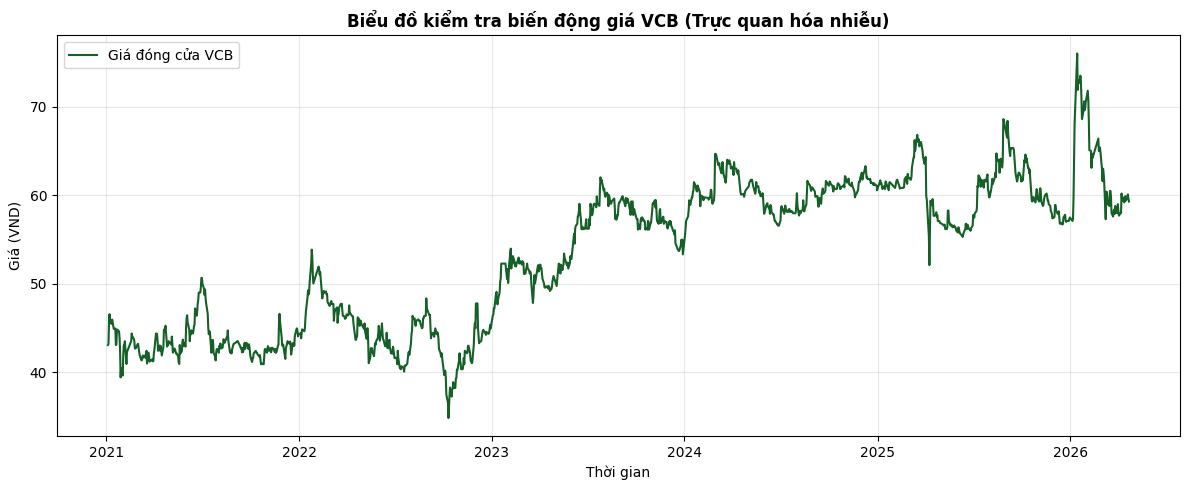

In [7]:
import sys
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Trỏ đường dẫn và kết nối Database
sys.path.append(os.path.abspath('./src'))
from data_loader import DB_PATH, get_connection

conn = get_connection()
df = pd.read_sql_query("SELECT * FROM Stock_Prices", conn)
conn.close()

df['Date'] = pd.to_datetime(df['Date'])

print("="*50)
print("BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (NGUỒN: KBS)")
print("="*50)

# 2. Kiểm tra dữ liệu rỗng hoặc bằng 0
print("\n1️⃣ KIỂM TRA GIÁ TRỊ RỖNG / ZERO:")
zero_close = df[df['Close'] <= 0]
zero_volume = df[df['Volume'] == 0]
print(f" ➔ Số dòng có giá Close <= 0: {len(zero_close)} dòng", "✅" if len(zero_close) == 0 else "❌")
print(f" ➔ Số dòng có Volume = 0    : {len(zero_volume)} dòng (Thường là các ngày ngưng giao dịch)")

# 3. Kiểm tra logic OHLC (Open, High, Low, Close)
print("\n2️⃣ KIỂM TRA LOGIC NẾN NHẬT (OHLC):")
invalid_ohlc = df[(df['High'] < df['Low']) | (df['High'] < df['Close']) | (df['Low'] > df['Close'])]
print(f" ➔ Số dòng có giá High/Low phi logic: {len(invalid_ohlc)} dòng", "✅" if len(invalid_ohlc) == 0 else "❌")
if len(invalid_ohlc) > 0:
    display(invalid_ohlc.head())

# 4. Kiểm tra độ đồng đều của 30 mã
print("\n3️⃣ KIỂM TRA SỰ ĐỒNG ĐỀU GIỮA CÁC MÃ TÀI SẢN:")
summary = df.groupby('Ticker').agg(
    Total_Rows=('Date', 'count'),
    Min_Date=('Date', 'min'),
    Max_Date=('Date', 'max')
)
median_rows = summary['Total_Rows'].median()
summary['Hụt_so_với_trung_bình'] = median_rows - summary['Total_Rows']

# Lọc ra các mã bị hụt quá 5% số dòng so với trung bình chung
missing_data_tickers = summary[summary['Hụt_so_với_trung_bình'] > (median_rows * 0.05)]
if len(missing_data_tickers) > 0:
    print(" ⚠️ CẢNH BÁO: Các mã sau có lượng dữ liệu hụt bất thường so với mặt bằng chung:")
    display(missing_data_tickers)
else:
    print(" ➔ Tất cả 30 mã đều có số lượng dữ liệu đồng đều. ✅")

# 5. Kiểm tra Outlier (Lỗi nhân dữ liệu hoặc chưa điều chỉnh giá)
print("\n4️⃣ KIỂM TRA OUTLIER (Biến động > 8%/ngày):")
# Tính % thay đổi giá hàng ngày cho từng mã
df = df.sort_values(['Ticker', 'Date'])
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

# Sàn HOSE biên độ 7%, nếu có ngày nào vọt > 8% (0.08) thì dữ liệu có vấn đề (vd: lỗi cổ tức)
outliers = df[(df['Daily_Return'] > 0.08) | (df['Daily_Return'] < -0.08)]
if len(outliers) > 0:
    print(f" ❌ CẢNH BÁO: Phát hiện {len(outliers)} điểm dữ liệu nghi ngờ sai lệch biên độ giá HOSE.")
    display(outliers[['Ticker', 'Date', 'Close', 'Daily_Return']].head(10))
else:
    print(" ➔ Không phát hiện biến động giá vượt trần/sàn bất hợp lý. Dữ liệu mượt mà. ✅")

# 6. Trực quan hóa kiểm tra mã đại diện 
ticker_test = 'VCB'
df_plot = df[df['Ticker'] == ticker_test]

plt.figure(figsize=(12, 5))
plt.plot(df_plot['Date'], df_plot['Close'], label=f'Giá đóng cửa {ticker_test}', color='#146026', linewidth=1.5)
plt.title(f'Biểu đồ kiểm tra biến động giá {ticker_test} (Trực quan hóa nhiễu)', fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Giá (VND)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()